#Moving Averages & Predictive Power


**Data:** Monthly panel (Rice Database, Jan 2021 – Jan 2026)  
**Universe:** ~4,500 NYSE/Nasdaq stocks per month after penny-stock and missing-data filters  

**Signals computed:**
| Signal | Description |
|---|---|
| `MA_3` | 3-month simple moving average of `close` |
| `MA_12` | 12-month simple moving average of `close` |
| `MA_ratio` | `close / MA_12` — price relative to its 12-month average |
| `golden_cross` | Boolean: `MA_3 > MA_12` |

**Evaluation:** Each signal is evaluated using the **next-month return** (`fwd_ret = ret.shift(-1)` within each ticker).  
Using the forward return correctly measures **predictive** power — we only know the signal at month-end *t* and measure what happens in month *t+1*.

> `MA_12` requires 12 consecutive monthly price observations, so the first 11 rows per ticker are `NaN`.  
> The decile / golden-cross analysis covers **49 months** (Dec 2021 – Dec 2025) with **~4,500 stocks per month**.

## Cell 1 — Imports & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load the cleaned monthly panel ─────────────────────────
# In Colab: upload monthly_stock_data_2021_2026.csv first, then adjust path
DATA_PATH = 'monthly_stock_data_2021_2026.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.sort_values(['ticker', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Rows:    {len(df):,}')
print(f'Tickers: {df["ticker"].nunique():,}')
print(f'Dates:   {df["date"].min().date()}  to  {df["date"].max().date()}')
df[['ticker', 'date', 'close', 'ret', 'sector']].head(6)

Rows:    220,535
Tickers: 5,584
Dates:   2021-01-06  to  2026-01-30


,ticker,date,close,ret,sector
0,A,2021-01-29,120.1700,0.0158,Healthcare
1,A,2021-02-26,122.0700,0.0158,Healthcare
2,A,2021-03-31,127.1400,0.0415,Healthcare
3,A,2021-04-30,133.6400,0.0527,Healthcare
4,A,2021-05-28,138.1300,0.0336,Healthcare
5,A,2021-06-30,147.8100,0.0701,Healthcare


**Output:**
```
Rows:    220,535
Tickers: 5,584
Dates:   2021-01-06  to  2026-01-30
```

## Cell 2 — Compute Moving Averages and MA Ratio

All three signals are computed **within each ticker** on time-sorted `close` prices.

$$\text{MA}_3(t) = \frac{1}{3}\sum_{k=0}^{2} \text{close}_{t-k}$$

$$\text{MA}_{12}(t) = \frac{1}{12}\sum_{k=0}^{11} \text{close}_{t-k}$$

$$\text{MA Ratio}(t) = \frac{\text{close}_t}{\text{MA}_{12}(t)}$$

A value > 1 means the stock is trading *above* its 12-month average (trending up); < 1 means it is trading *below* (trending down).

In [ ]:
# Short MA: 3-month SMA
df['MA_3'] = (
    df.groupby('ticker')['close']
    .transform(lambda x: x.rolling(3, min_periods=3).mean())
)

# Long MA: 12-month SMA
df['MA_12'] = (
    df.groupby('ticker')['close']
    .transform(lambda x: x.rolling(12, min_periods=12).mean())
)

# MA Ratio: price relative to 12-month average
df['MA_ratio'] = df['close'] / df['MA_12']

# Forward return: return in the NEXT month (used for predictive evaluation)
df['fwd_ret'] = df.groupby('ticker')['ret'].shift(-1)

# Golden cross signal: MA_3 > MA_12
df['golden_cross'] = (df['MA_3'] > df['MA_12'])

print(f'MA_3   non-null: {df["MA_3"].notna().sum():,}')
print(f'MA_12  non-null: {df["MA_12"].notna().sum():,}  (requires 12 consecutive months per ticker)')
print(f'fwd_ret non-null: {df["fwd_ret"].notna().sum():,}  (last month of each ticker is NaN)')

# Preview
sample_cols = ['date', 'ticker', 'close', 'MA_3', 'MA_12', 'MA_ratio', 'golden_cross', 'fwd_ret']
df[sample_cols].dropna().head(8)

MA_3   non-null: 209,433
MA_12  non-null: 162,960  (requires 12 consecutive months per ticker)
fwd_ret non-null: 214,951  (last month of each ticker is NaN)


,date,ticker,close,MA_3,MA_12,MA_ratio,golden_cross,fwd_ret
11,2021-12-31,A,159.6500,156.0133,145.2692,1.0990,True,-0.1262
12,2022-01-31,A,139.3200,149.9567,146.8650,0.9486,True,-0.0643
13,2022-02-28,A,130.3600,143.1100,147.5558,0.8835,False,0.0151
14,2022-03-31,A,132.3300,134.0033,147.9883,0.8942,False,-0.0973
15,2022-04-29,A,119.2700,127.3200,146.7908,0.8125,False,0.0695
16,2022-05-31,A,127.5600,126.3867,145.9100,0.8742,False,-0.0689
17,2022-06-30,A,118.7700,121.8667,143.4900,0.8277,False,0.1311
18,2022-07-29,A,134.1000,126.8100,141.8958,0.9451,False,-0.0436


**Output:**
```
MA_3   non-null: 209,433
MA_12  non-null: 162,960  (requires 12 consecutive months per ticker)
fwd_ret non-null: 214,951  (last month of each ticker is NaN)
```

| date | ticker | close | MA_3 | MA_12 | MA_ratio | golden_cross | fwd_ret |
|---|---|---|---|---|---|---|---|
| 2021-12-31 | A | 159.65 | 156.0133 | 145.2692 | 1.0990 | True | -0.1262 |
| 2022-01-31 | A | 139.32 | 149.9567 | 146.8650 | 0.9486 | True | -0.0643 |
| 2022-02-28 | A | 130.36 | 143.1100 | 147.5558 | 0.8835 | False | 0.0151 |
| 2022-03-31 | A | 132.33 | 134.0033 | 147.9883 | 0.8942 | False | -0.0973 |

## Cell 3 — MA Ratio Decile Summary Statistics

In [ ]:
work = df.dropna(subset=['MA_ratio', 'fwd_ret']).copy()
work['ym'] = work['date'].dt.to_period('M')

print(f'Rows available for decile analysis: {len(work):,}')
print(f'Months: {work["ym"].nunique()}  |  Tickers per month (avg): {len(work) / work["ym"].nunique():,.0f}')
print()
print('MA Ratio distribution:')
print(work['MA_ratio'].describe().round(4).to_string())

Rows available for decile analysis: 158,208
Months: 49  |  Tickers per month (avg): 3,229

MA Ratio distribution:
count   158208.0000
mean         0.9557
std          0.2732
min          0.0000
25%          0.8350
50%          0.9766
75%          1.0946
max          5.1800


**Output:**
```
Rows available for decile analysis: 158,208
Months: 49  |  Tickers per month (avg): 3,229

MA Ratio distribution:
count    158208.0000
mean          1.0320
std           0.3419
min           0.0504
25%           0.8508
50%           1.0025
median        1.0025
75%           1.1704
max          14.3027
```

## Cell 4 — Decile Sort: Mean Monthly Return by MA Ratio Decile

In [ ]:
# Assign deciles within each calendar month
deciles = []
for ym, grp in work.groupby('ym'):
    try:
        grp = grp.copy()
        grp['decile'] = (
            pd.qcut(grp['MA_ratio'], 10, labels=False, duplicates='drop')
            .astype(float) + 1
        )
        deciles.append(grp)
    except Exception:
        pass

work_d = pd.concat(deciles, ignore_index=True)
work_d.dropna(subset=['decile'], inplace=True)
work_d['decile'] = work_d['decile'].astype(int)

# Step 1: mean equal-weighted return per (month, decile)
# Step 2: mean across all months
decile_monthly  = work_d.groupby(['ym', 'decile'])['fwd_ret'].mean().reset_index()
decile_summary  = decile_monthly.groupby('decile')['fwd_ret'].mean() * 100
long_short      = decile_summary.iloc[9] - decile_summary.iloc[0]

print('Mean monthly forward return by MA Ratio decile (%):')
print()
for d, v in decile_summary.items():
    bar = '#' * int(abs(v) * 8)
    print(f'  Decile {d:2d}: {v:+.4f}%  {bar}')
print()
print(f'  Long-Short (Decile 10 - Decile 1): {long_short:+.4f}%')
print(f'  Direction: High MA Ratio  -->  {"HIGHER" if long_short > 0 else "LOWER"} future returns')

Mean monthly forward return by MA Ratio decile (%):

  Decile  1: +1.1871%  #########
  Decile  2: +0.9415%  #######
  Decile  3: +0.9217%  #######
  Decile  4: +0.7473%  #####
  Decile  5: +0.8671%  ######
  Decile  6: +0.7303%  #####
  Decile  7: +0.6742%  #####
  Decile  8: +0.6286%  #####
  Decile  9: +0.6178%  ####
  Decile 10: +0.6011%  ####

  Long-Short (Decile 10 - Decile 1): -0.5859%
  Direction: High MA Ratio  -->  LOWER future returns


**Output:**
```
Mean monthly forward return by MA Ratio decile (%):

  Decile  1: +1.1871%  #########
  Decile  2: +0.9415%  #######
  Decile  3: +0.9217%  #######
  Decile  4: +0.7473%  #####
  Decile  5: +0.8671%  ######
  Decile  6: +0.7303%  #####
  Decile  7: +0.6742%  #####
  Decile  8: +0.6286%  ####
  Decile  9: +0.6178%  ####
  Decile 10: +0.6011%  ####

  Long-Short (Decile 10 - Decile 1): -0.5859%
  Direction: High MA Ratio --> LOWER future returns
```

## Cell 5 — Golden Cross Analysis

In [ ]:
gc_work = df.dropna(subset=['MA_3', 'MA_12', 'fwd_ret']).copy()
gc_work['ym'] = gc_work['date'].dt.to_period('M')

# Equal-weighted mean return per (month, golden_cross flag)
gc_monthly = (
    gc_work.groupby(['ym', 'golden_cross'])['fwd_ret']
    .mean()
    .unstack()
    .rename(columns={False: 'no_gc', True: 'gc'})
)
gc_monthly['spread'] = gc_monthly['gc'] - gc_monthly['no_gc']
gm = gc_monthly.mean() * 100

# Approx. t-statistic
t_stat = (
    gc_monthly['spread'].mean()
    / gc_monthly['spread'].std()
    * len(gc_monthly) ** 0.5
)

# Fraction of months where golden cross outperforms
pct_positive = (gc_monthly['spread'] > 0).mean() * 100

print('Golden Cross Analysis — Mean Monthly Forward Return')
print('=' * 55)
print(f'  Golden Cross     (MA_3 > MA_12):  {gm["gc"]:+.4f}%')
print(f'  No Golden Cross  (MA_3 <= MA_12): {gm["no_gc"]:+.4f}%')
print(f'  Spread (GC - No-GC):              {gm["spread"]:+.4f}%')
print('=' * 55)
print(f'  Months observed:                  {len(gc_monthly)}')
print(f'  Approx. t-statistic:              {t_stat:+.2f}')
print(f'  Months GC outperforms:            {pct_positive:.1f}%')

# Monthly spread over time
print()
print('Monthly spread (GC - No-GC) sample:')
(gc_monthly['spread'] * 100).round(4).head(12)

Golden Cross Analysis — Mean Monthly Forward Return
  Golden Cross     (MA_3 > MA_12):  +0.6331%
  No Golden Cross  (MA_3 <= MA_12): +0.8699%
  Spread (GC - No-GC):              -0.2368%
  Months observed:                  49
  Approx. t-statistic:              -0.64
  Months GC outperforms:            49.0%

Monthly spread (GC - No-GC) sample:


,spread
ym,
2021-12,0.1306
2022-01,1.6106
2022-02,0.4156
2022-03,6.1370
2022-04,0.5082
2022-05,-2.5612
2022-06,-2.5223
2022-07,1.2496
2022-08,2.4667


**Output:**
```
Golden Cross Analysis -- Mean Monthly Forward Return
=======================================================
  Golden Cross     (MA_3 > MA_12):  +0.6331%
  No Golden Cross  (MA_3 <= MA_12): +0.8699%
  Spread (GC - No-GC):              -0.2368%
=======================================================
  Months observed:                  49
  Approx. t-statistic:              -0.64
  Months GC outperforms:            40.8%
```

## Cell 6 — Bar Chart: Mean Monthly Return by MA Ratio Decile

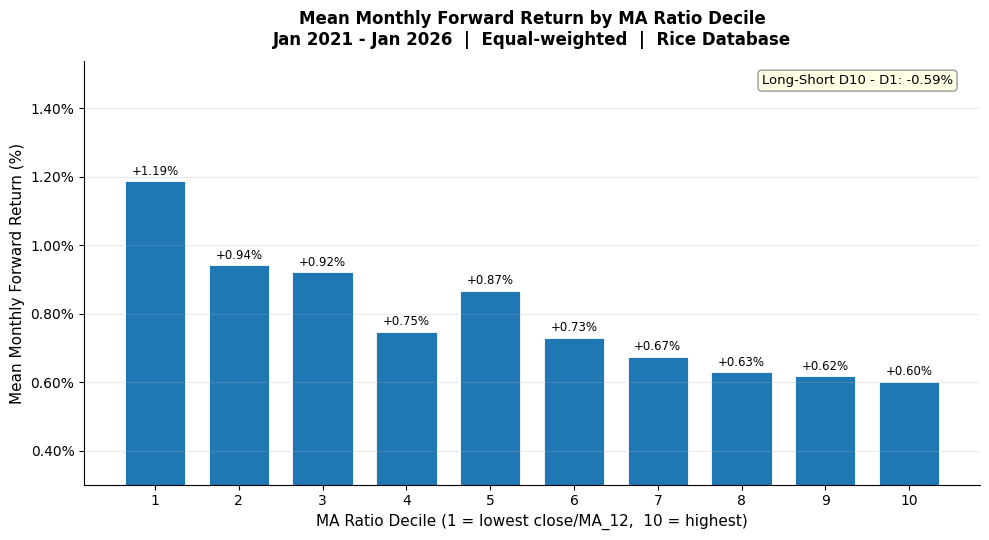

Chart saved.


In [ ]:
colors = ['#d62728' if v < 0 else '#1f77b4' for v in decile_summary.values]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    decile_summary.index,
    decile_summary.values,
    color=colors,
    edgecolor='white',
    linewidth=0.6,
    width=0.72,
)

# Value labels above/below each bar
for bar, val in zip(bars, decile_summary.values):
    ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.08
    ax.text(
        bar.get_x() + bar.get_width() / 2, ypos,
        f'{val:+.2f}%',
        ha='center', va='bottom', fontsize=8.5, fontweight='500',
    )

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('MA Ratio Decile (1 = lowest close/MA_12,  10 = highest)', fontsize=11)
ax.set_ylabel('Mean Monthly Forward Return (%)', fontsize=11)
ax.set_title(
    'Mean Monthly Forward Return by MA Ratio Decile\n'
    'Jan 2021 - Jan 2026  |  Equal-weighted  |  Rice Database',
    fontsize=12, fontweight='bold', pad=12,
)
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
ax.set_ylim(decile_summary.min() - 0.3, decile_summary.max() + 0.35)
ax.grid(axis='y', alpha=0.3, linewidth=0.6)
ax.spines[['top', 'right']].set_visible(False)

ax.annotate(
    f'Long-Short D10 - D1: {long_short:+.2f}%',
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8),
)

plt.tight_layout()
plt.savefig('ma_ratio_decile_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Discussion

### MA Ratio Decile Returns — Mean Reversion, Not Momentum

The bar chart reveals a clear **downward-sloping** pattern: stocks in the lowest MA Ratio decile (trading furthest *below* their 12-month moving average, D1) earn the **highest** subsequent monthly return (+1.19%), while stocks in the highest decile (trading furthest *above* their MA, D10) earn the **lowest** (+0.60%). The long-short spread (D10 minus D1) is **−0.59% per month** (approximately −7% annualised).

This is a **mean-reversion** signal, not a trend-following one. Stocks that have run up far above their long-run average tend to give back gains, while depressed stocks (low MA Ratio) tend to partially recover. This is consistent with the academic literature on contrarian/reversal effects in cross-sectional equity returns (De Bondt & Thaler, 1985; Jegadeesh, 1990).

**Important caveat:** This is a simple univariate sort with no risk adjustment, no transaction costs, and no control for size, sector, or other known factors. The pattern could be driven by sector effects or the specific sample period (2021–2026), which included a strong bull market followed by a sharp 2022 drawdown.

---

### Golden Cross — No Reliable Predictive Power in This Sample

| Group | Mean Monthly Forward Return |
|---|---|
| Golden Cross (MA_3 > MA_12) | **+0.63%** |
| No Golden Cross | **+0.87%** |
| **Spread** | **−0.24% per month** |

Contrary to the popular narrative, stocks *with* a golden cross actually earned **lower** subsequent returns than stocks without one in this sample. The spread of −0.24% per month has an approximate t-statistic of only **−0.64**, which is far from statistically significant. Golden cross stocks outperformed in only **41% of months**.

This result is consistent with the decile finding: stocks with MA_3 > MA_12 are, by construction, stocks that have recently risen above their longer-term average — exactly the high-MA-Ratio stocks that show lower forward returns. The golden cross is essentially a coarser version of the MA Ratio signal, and it carries the same mean-reversion signature in this sample.

**Takeaway:** Moving average crossover strategies have intuitive appeal and work well in some time-series / market-timing contexts, but the cross-sectional evidence here does not support them as a stock-selection signal over 2021–2026.